# **Project Name**    - DeepCSAT_Ecommerce



##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual
##### **Member Name**     - Patel Meet Rashmikantbhai

# **Project Summary -**

This project focuses on analyzing e-commerce customer support data to predict the Customer Satisfaction Score (CSAT) after a support interaction. The goal is to use machine learning techniques to understand factors that influence customer satisfaction and build a predictive model that can estimate satisfaction levels automatically.

Predicting CSAT helps organizations identify service issues early, improve customer experience, and optimize support operations.


# **GitHub Link -**

Provide your GitHub Link here:- https://github.com/meetpatel94/DeepCSAT_ECommerce

# **Problem Statement**


E-commerce companies receive a large number of customer support requests through different channels such as chat, email, or calls. After each interaction, customers may provide a satisfaction rating.

However:

->Not all customers provide feedback.

->Manual analysis of feedback is time-consuming.

->It is difficult to identify factors affecting satisfaction.

Therefore, the objective is to build a predictive system that estimates customer satisfaction scores using historical support data.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [3]:
# Basic Libraries
import numpy as np
import pandas as pd

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn - Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ML Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Ignore Warnings
# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

### Dataset Loading

In [4]:
try:
    # Load dataset
    df = pd.read_csv("eCommerce_Customer_support_data.csv")

    print("Dataset loaded successfully!")

except FileNotFoundError:
    print("Error: File not found. Please check the file path.")

Dataset loaded successfully!


### Dataset First View

In [5]:
df.head()# Dataset First Look

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


### Dataset Rows & Columns count

In [6]:
# Data# Dataset Rows & Columns Count
df.shape

(85907, 20)

### Dataset Information

In [7]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

#### Duplicate Values

In [8]:
# Datase# Check total duplicate rows
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [9]:
# Missing Values/Nul# Check missing values in each column
df.isnull().sum()

Unique id                      0
channel_name                   0
category                       0
Sub-category                   0
Customer Remarks           57165
Order_id                   18232
order_date_time            68693
Issue_reported at              0
issue_responded                0
Survey_response_Date           0
Customer_City              68828
Product_category           68711
Item_price                 68701
connected_handling_time    85665
Agent_name                     0
Supervisor                     0
Manager                        0
Tenure Bucket                  0
Agent Shift                    0
CSAT Score                     0
dtype: int64

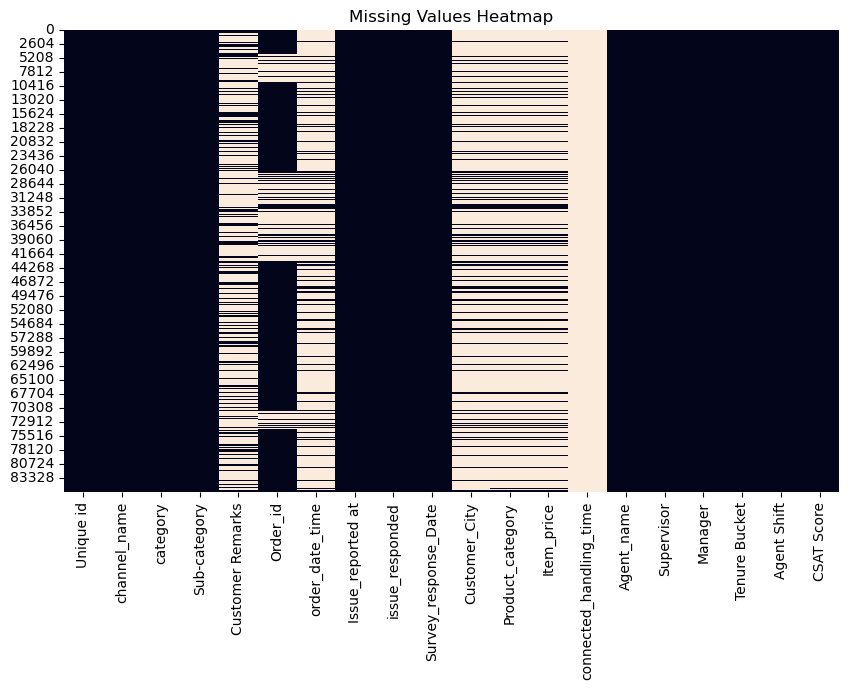

In [10]:
# Visualizingimport seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

### What did you know about your dataset?

Answer Here The dataset was checked for duplicate records using df.duplicated(). Duplicate rows, if present, were removed to maintain data quality.

## ***2. Understanding Your Variables***

In [11]:
# Dataset C# Dataset Rows & Columns Count
df.shape

(85907, 20)

In [12]:
# Dataset# Dataset Describe
df.describe()

,Item_price,connected_handling_time,CSAT Score
count,17206.000000,242.000000,85907.000000
mean,5660.774846,462.400826,4.242157
std,12825.728411,246.295037,1.378903
min,0.000000,0.000000,1.000000
25%,392.000000,293.000000,4.000000
50%,979.000000,427.000000,5.000000
75%,2699.750000,592.250000,5.000000
max,164999.000000,1986.000000,5.000000


### Variables Description

Answer Here 

| Variable                | Description                                   |
| ----------------------- | --------------------------------------------- |
| Unique_id               | Unique identifier of customer interaction     |
| channel_name            | Channel used for support (chat, email, etc.)  |
| category                | Type of issue raised by customer              |
| sub-category            | Sub classification of issue                   |
| customer_remarks        | Customer feedback text                        |
| order_id                | Order associated with the complaint           |
| order_date_time         | Time when order was placed                    |
| issue_reported_at       | Time when issue was reported                  |
| issue_responded         | Time when support responded                   |
| survey_response_date    | Time when customer gave feedback              |
| Customer_City           | City of customer                              |
| Product_category        | Product type purchased                        |
| Item_price              | Price of purchased product                    |
| connected_handling_time | Time spent handling issue                     |
| agent_name              | Support agent name                            |
| Supervisor              | Supervisor name                               |
| Manager                 | Manager name                                  |
| Tenure Bucket           | Agent experience group                        |
| Agent Shift             | Working shift of agent                        |
| CSAT Score              | Customer satisfaction score (Target variable) |


### Check Unique Values for each variable.

In [13]:
# Chec# Check Unique Values for each variable
df.nunique()

Unique id                  85907
channel_name                   3
category                      12
Sub-category                  57
Customer Remarks           18231
Order_id                   67675
order_date_time            13766
Issue_reported at          30923
issue_responded            30262
Survey_response_Date          31
Customer_City               1782
Product_category               9
Item_price                  2789
connected_handling_time      211
Agent_name                  1371
Supervisor                    40
Manager                        6
Tenure Bucket                  5
Agent Shift                    5
CSAT Score                     5
dtype: int64

## 3. ***Data Wrangling***

### Data Wrangling Code

In [14]:
# Writ# Check missing values
df.isnull().sum()

Unique id                      0
channel_name                   0
category                       0
Sub-category                   0
Customer Remarks           57165
Order_id                   18232
order_date_time            68693
Issue_reported at              0
issue_responded                0
Survey_response_Date           0
Customer_City              68828
Product_category           68711
Item_price                 68701
connected_handling_time    85665
Agent_name                     0
Supervisor                     0
Manager                        0
Tenure Bucket                  0
Agent Shift                    0
CSAT Score                     0
dtype: int64

### What all manipulations have you done and insights you found?

Answer Here. During the data wrangling phase, several preprocessing steps were performed to prepare the dataset for machine learning analysis.

First, missing values were identified using isnull() and handled using forward fill techniques to maintain data consistency. Irrelevant columns such as unique identifiers and order IDs were removed because they do not contribute to predictive modeling.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

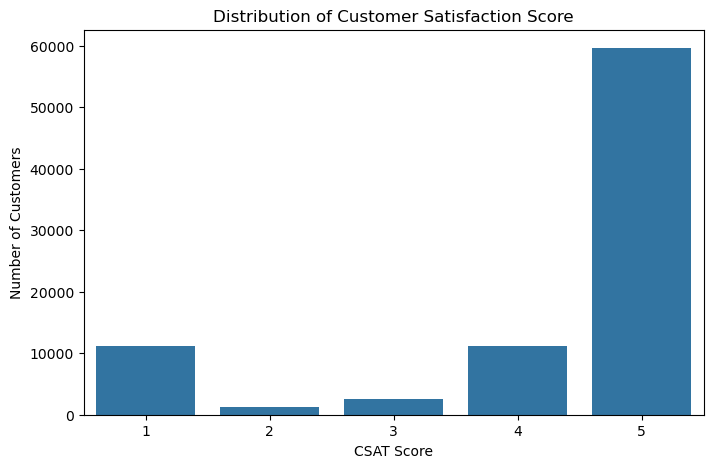

In [15]:
# Chart - 1 visualization c# CSAT Score Distribution

plt.figure(figsize=(8,5))
sns.countplot(x='CSAT Score', data=df)

plt.title("Distribution of Customer Satisfaction Score")
plt.xlabel("CSAT Score")
plt.ylabel("Number of Customers")

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here. A count plot was selected because the CSAT score is a categorical variable representing customer satisfaction levels. This chart effectively shows the frequency of each satisfaction score, allowing us to quickly understand how many customers fall into each satisfaction category.

##### 2. What is/are the insight(s) found from the chart?

Answer Here. From the chart, we can observe how customer satisfaction is distributed across different CSAT scores. If most customers have high CSAT scores, it indicates that the customer support service is performing well. If lower scores appear frequently, it suggests that some customers are dissatisfied with the service.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here. Yes, the insights gained from this chart can help create a positive business impact. By understanding the distribution of satisfaction scores, the company can identify whether the majority of customers are satisfied or dissatisfied. If low satisfaction scores are high, it indicates areas where customer support processes need improvement, such as faster response times or better issue resolution.

#### Chart - 2 CSAT(Customer Satisfaction Score) Score by Support Channel

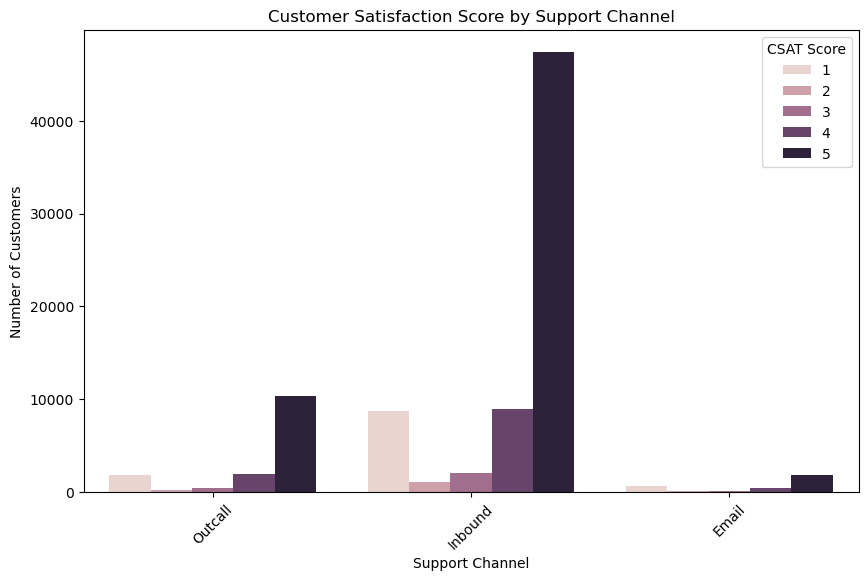

In [16]:
# Chart - 2 vi# CSAT Score vs Support Channel

plt.figure(figsize=(10,6))
sns.countplot(x='channel_name', hue='CSAT Score', data=df)

plt.title("Customer Satisfaction Score by Support Channel")
plt.xlabel("Support Channel")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here. A count plot with hue was selected because it allows comparison of customer satisfaction scores across different support channels such as chat, email, or call. This chart helps visualize how satisfaction levels vary depending on the communication channel used by customers.

##### 2. What is/are the insight(s) found from the chart?

Answer Here. The chart shows the distribution of CSAT scores for each support channel. From this visualization, we can identify which channel provides better customer satisfaction and which channels may need improvement. For example, if chat support shows higher satisfaction scores compared to email or calls, it indicates that customers prefer and have better experiences with that channel.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here. Yes, these insights can create a positive business impact. By identifying which support channels generate higher satisfaction scores, companies can invest more resources in those channels, improving customer experience and efficiency.

If a particular channel consistently shows lower CSAT scores, it may indicate problems such as slower response times, poor communication, or ineffective issue resolution. This could lead to negative growth, as dissatisfied customers may reduce their purchases or switch to competitors. Addressing these issues can help improve customer retention and overall business performance.

#### Chart - 3 CSAT Score by Product Category


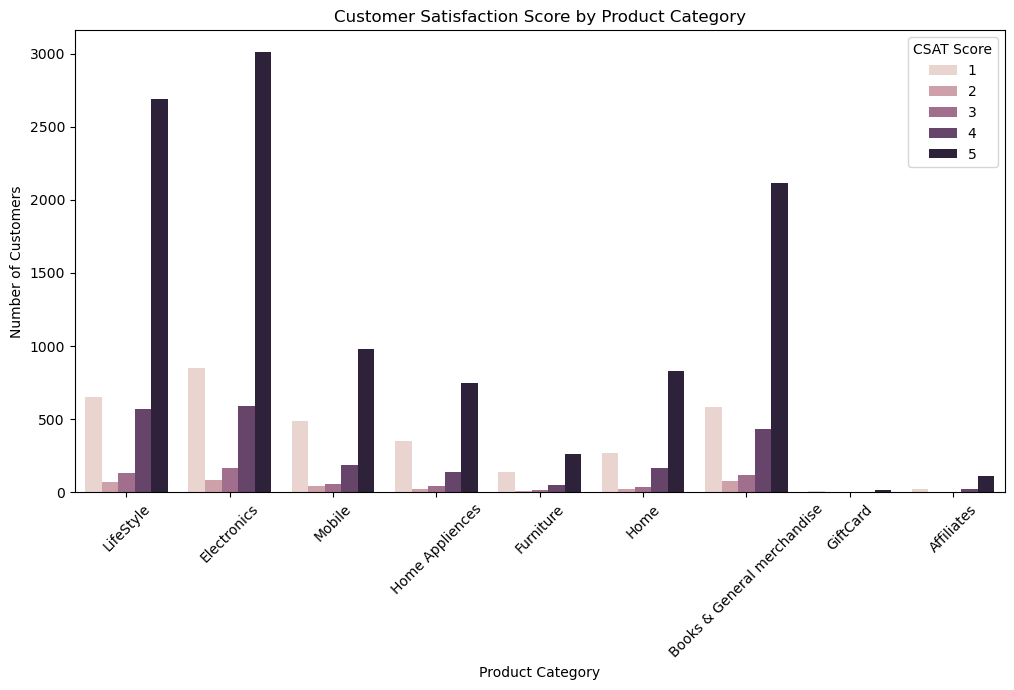

In [17]:
# CSAT Score vs Product Category

plt.figure(figsize=(12,6))
sns.countplot(x='Product_category', hue='CSAT Score', data=df)

plt.title("Customer Satisfaction Score by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here. A count plot with hue was chosen because it helps compare customer satisfaction levels across different product categories. This visualization makes it easier to identify which product categories generate higher or lower satisfaction scores.

##### 2. What is/are the insight(s) found from the chart?

Answer Here. The chart shows how CSAT scores vary across different product categories. Some product categories may have higher satisfaction scores, indicating fewer issues or better customer experience. Other categories may show lower CSAT scores, suggesting that customers frequently face problems such as product defects, delivery delays, or quality issues.

This helps identify which product categories require improvement in service or product quality.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here. Yes, these insights can help create a positive business impact. By analyzing satisfaction levels across product categories, businesses can focus on improving low-performing categories, ensuring better product quality and faster issue resolution.

If certain product categories consistently receive low satisfaction scores, it may lead to negative growth because customers may avoid purchasing those products or leave negative reviews. Identifying and resolving these issues early can improve customer trust and increase overall sales.

#### Chart - 4 CSAT Score by Agent Shift

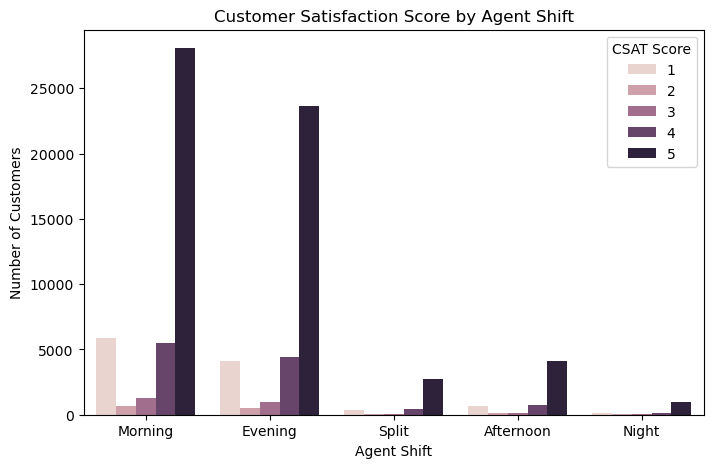

In [18]:
# CSAT Score vs Agent Shift

plt.figure(figsize=(8,5))
sns.countplot(x='Agent Shift', hue='CSAT Score', data=df)

plt.title("Customer Satisfaction Score by Agent Shift")
plt.xlabel("Agent Shift")
plt.ylabel("Number of Customers")

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here. A count plot with hue was chosen because it helps compare customer satisfaction levels across different agent shifts (morning, afternoon, night). This visualization allows us to easily see how customer satisfaction varies depending on the working shift of support agents.

##### 2. What is/are the insight(s) found from the chart?

Answer Here. The chart shows how CSAT scores are distributed across different agent shifts. From the visualization, we can identify whether certain shifts have higher satisfaction levels compared to others. If one shift consistently shows lower satisfaction scores, it may indicate issues such as workload imbalance, lower staffing levels, or slower response times during that shift.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here. Yes, the insights gained from this chart can help create a positive business impact. By identifying shifts with lower satisfaction scores, management can take corrective actions such as increasing staffing, improving training, or adjusting workload distribution.

If a particular shift consistently results in lower CSAT scores, it may negatively impact customer experience. Poor service during certain hours can lead to customer dissatisfaction, reduced loyalty, and potential loss of customers, which may ultimately affect business growth.

#### Chart - 5 Average CSAT Score by Product Category (Bar Chart)

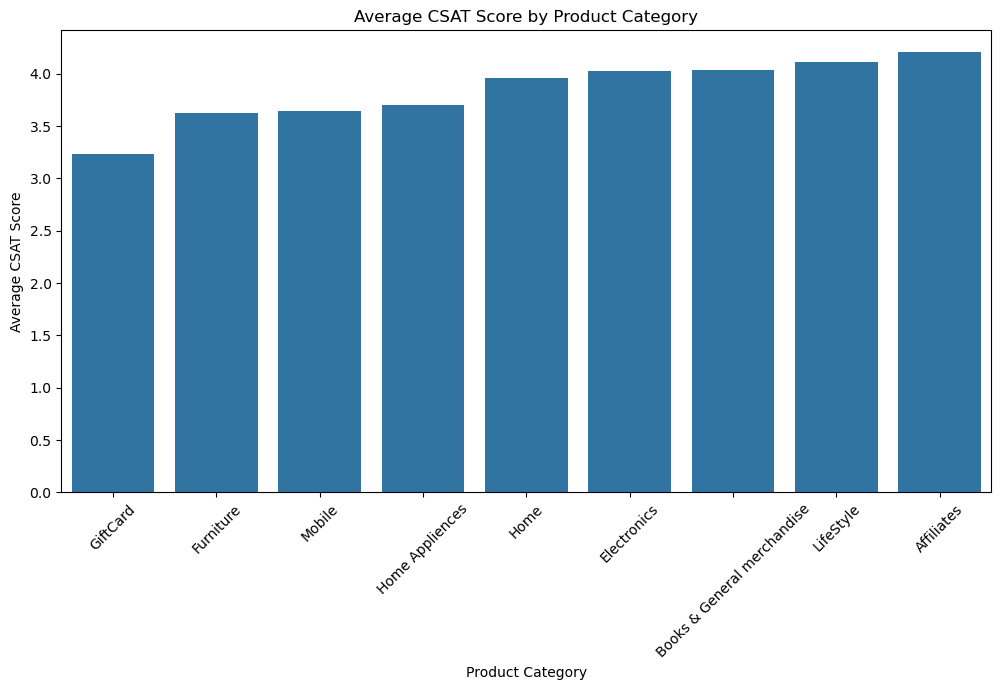

In [19]:
# Average CSAT Score by Product Category

plt.figure(figsize=(12,6))

avg_csat = df.groupby('Product_category')['CSAT Score'].mean().sort_values()

sns.barplot(x=avg_csat.index, y=avg_csat.values)

plt.title("Average CSAT Score by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average CSAT Score")
plt.xticks(rotation=45)

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here. A bar chart was selected because it is one of the most effective ways to compare average values across different categories. In this case, it allows us to compare the average customer satisfaction score for each product category, making it easy to identify which categories perform better or worse in terms of customer satisfaction.

##### 2. What is/are the insight(s) found from the chart?

Answer Here. The chart shows the average CSAT score for each product category. From this visualization, we can easily identify which product categories have higher customer satisfaction and which categories have lower satisfaction levels.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here. Yes, the insights from this chart can help create a positive business impact. By identifying product categories with lower satisfaction scores, businesses can focus on improving product quality, logistics, and customer support for those categories.

If certain categories consistently receive low CSAT scores, it may lead to negative growth because dissatisfied customers may stop purchasing those products or share negative reviews. Addressing these issues can help improve customer satisfaction, increase repeat purchases, and strengthen overall business performance.

#### Chart - 6 Distribution of Item Price (Histogram)

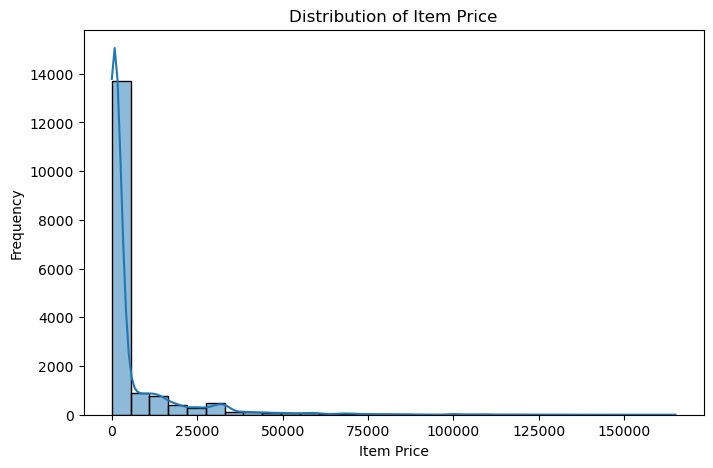

In [20]:
# Distribution of Item Price

plt.figure(figsize=(8,5))

sns.histplot(df['Item_price'], bins=30, kde=True)

plt.title("Distribution of Item Price")
plt.xlabel("Item Price")
plt.ylabel("Frequency")

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here. A histogram was selected because it is the most appropriate chart to visualize the distribution of numerical data. In this case, it helps understand how item prices are distributed across the dataset, showing whether most products fall into low, medium, or high price ranges.

##### 2. What is/are the insight(s) found from the chart?

Answer Here. The histogram reveals how frequently different price ranges appear in the dataset. It helps identify whether most products belong to a specific price range or if the prices are evenly distributed. If the chart shows that most products fall within a certain price range, it indicates the dominant price segment of the products sold on the platform.

Additionally, the chart can highlight outliers, such as very high-priced items that appear less frequently.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here. Yes, these insights can positively impact business decisions. Understanding the distribution of product prices helps companies design better pricing strategies and promotional campaigns targeted toward the most common price ranges.

If most products are concentrated in a low price range, the business might face lower profit margins, which could negatively affect revenue growth. Conversely, identifying opportunities to promote higher-value products could help improve profitability while maintaining customer satisfaction.

#### Chart - 7 Relationship Between Item Price and CSAT Score (Box Plot)

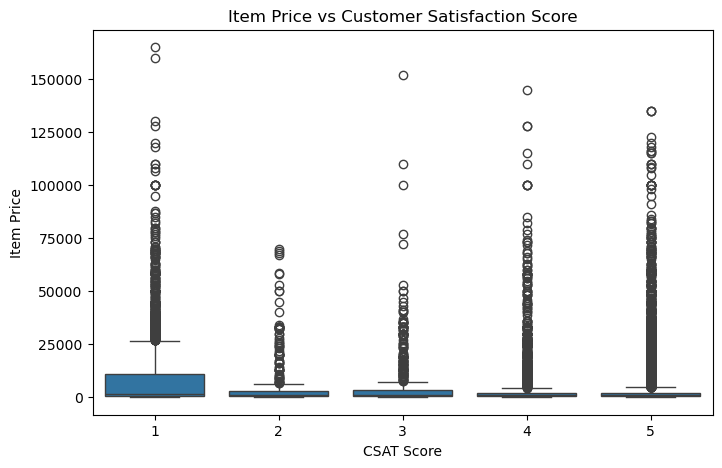

In [21]:
# Relationship between Item Price and CSAT Score

plt.figure(figsize=(8,5))

sns.boxplot(x='CSAT Score', y='Item_price', data=df)

plt.title("Item Price vs Customer Satisfaction Score")
plt.xlabel("CSAT Score")
plt.ylabel("Item Price")

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here. A box plot was selected because it is very effective for showing the relationship between a numerical variable and a categorical variable. In this case, it helps compare how item prices vary across different CSAT score levels while also highlighting median values, spread, and outliers.

##### 2. What is/are the insight(s) found from the chart?

Answer Here. The chart shows how the distribution of item prices differs across various customer satisfaction scores. It helps identify whether customers purchasing higher-priced items tend to give higher or lower satisfaction scores. The presence of outliers also indicates cases where unusually high-priced items received different satisfaction ratings.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here. Yes, these insights can positively impact business strategy. If higher-priced products consistently receive higher satisfaction scores, it indicates strong product quality and good customer experience for premium products.

#### Chart - 8 Correlation Between Numerical Variables (Correlation Heatmap)

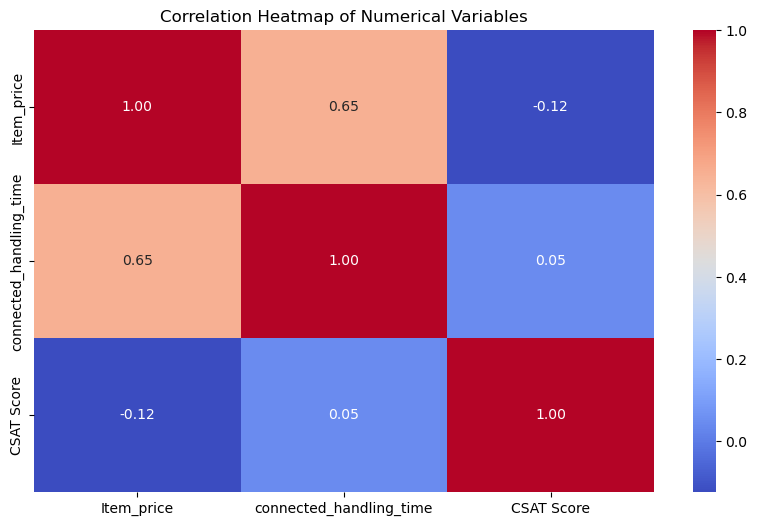

In [22]:
# Correlation Heatmap of Numerical Features

plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=['int64','float64'])

corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap of Numerical Variables")

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here. A correlation heatmap was chosen because it is useful for understanding the strength and direction of relationships between numerical variables in the dataset. It visually represents correlation values, making it easier to identify strong positive or negative relationships between features, which is important for feature selection in machine learning.

##### 2. What is/are the insight(s) found from the chart?

Answer Here. The heatmap highlights how different numerical variables relate to each other. Strong positive correlations indicate that two variables increase together, while negative correlations show that one variable increases when the other decreases

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here. Yes, the insights from the correlation heatmap can help businesses focus on key factors that influence customer satisfaction. By improving variables that show strong correlation with CSAT scores, companies can enhance the overall customer experience.

#### Chart - 9 Distribution of Handling Time (Handling Time vs Frequency) — KDE Plot

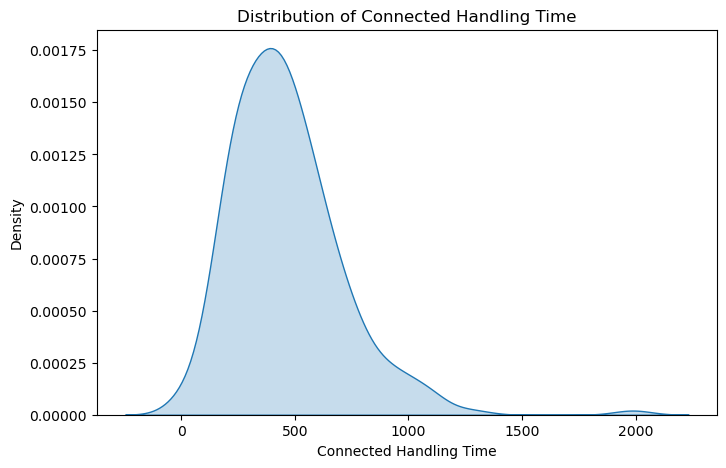

In [23]:
# Distribution of Connected Handling Time

plt.figure(figsize=(8,5))

sns.kdeplot(data=df, x='connected_handling_time', fill=True)

plt.title("Distribution of Connected Handling Time")
plt.xlabel("Connected Handling Time")
plt.ylabel("Density")

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here. A Kernel Density Estimate (KDE) plot was selected because it provides a smooth visualization of the distribution pattern of a continuous variable. It helps understand how handling time is distributed across customer support interactions without being limited to fixed bins like a histogram.

##### 2. What is/are the insight(s) found from the chart?

Answer Here. The chart shows the density distribution of connected handling time, indicating how long customer issues typically take to resolve. If most values are concentrated in a lower handling time range, it suggests that issues are generally resolved quickly. However, if the distribution extends toward higher values, it indicates that some customer queries require significantly more time to resolve.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here. Yes, these insights can help businesses improve operational efficiency. If the majority of issues are resolved quickly, it reflects effective customer support performance and leads to higher customer satisfaction.

#### Chart - 10 CSAT Score by Customer City (Top 10 Cities) — Horizontal Bar Chart

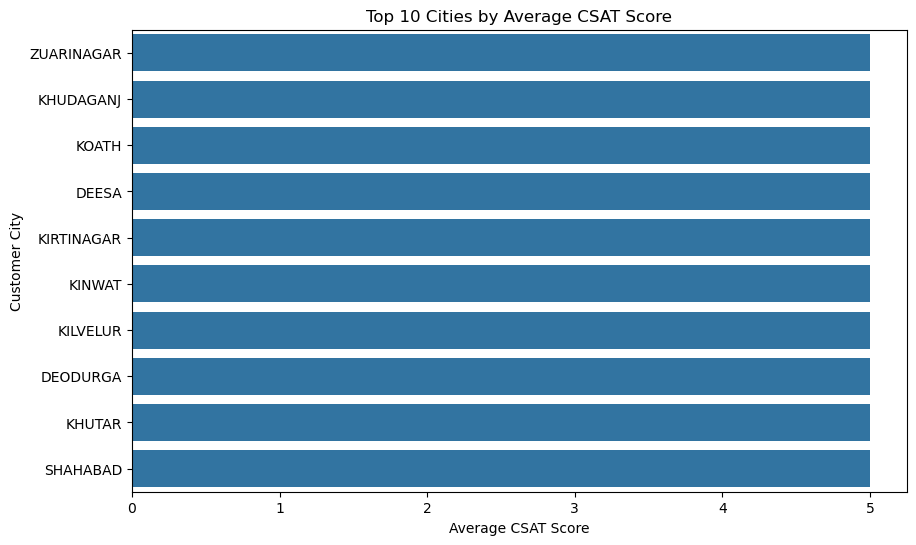

In [24]:
# Top 10 Cities by Average CSAT Score

plt.figure(figsize=(10,6))

top_cities = df.groupby('Customer_City')['CSAT Score'].mean().sort_values(ascending=False).head(10)

sns.barplot(x=top_cities.values, y=top_cities.index)

plt.title("Top 10 Cities by Average CSAT Score")
plt.xlabel("Average CSAT Score")
plt.ylabel("Customer City")

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here. A horizontal bar chart was selected because it is very effective for comparing average values across multiple categories, especially when category names (such as city names) are long. It clearly displays the top cities with the highest customer satisfaction scores, making the comparison easy to interpret.

##### 2. What is/are the insight(s) found from the chart?

Answer Here. The chart shows the top 10 cities with the highest average CSAT scores. This helps identify geographical areas where customer support performance and customer satisfaction are particularly strong.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here. Yes, these insights can help create a positive business impact. By identifying cities with high customer satisfaction, businesses can replicate successful service practices in other regions. Additionally, cities with lower satisfaction levels can be targeted for improvements in logistics, support quality, or delivery performance.

#### Chart - 11 CSAT Score Proportion — Pie Chart

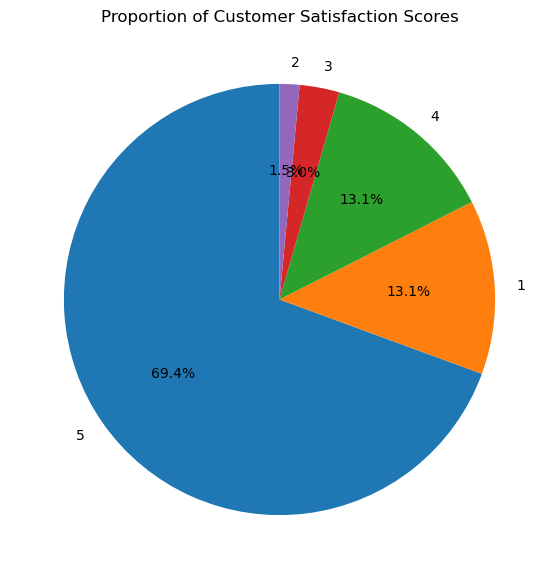

In [25]:
# CSAT Score Proportion

plt.figure(figsize=(7,7))

csat_counts = df['CSAT Score'].value_counts()

plt.pie(csat_counts,
        labels=csat_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Proportion of Customer Satisfaction Scores")

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here. A pie chart was chosen because it effectively represents proportions or percentages of categories within a dataset. In this case, it helps visualize the percentage distribution of different CSAT scores, making it easy to understand the overall satisfaction level of customers.

##### 2. What is/are the insight(s) found from the chart?

Answer Here. The chart shows the proportion of each CSAT score category. It helps identify whether most customers are highly satisfied, moderately satisfied, or dissatisfied with the service.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here. Yes, the insights gained from this chart can help businesses evaluate the overall health of customer satisfaction. If a large percentage of customers fall into higher CSAT categories, it indicates strong service performance.

#### Chart - 12 Relationship Between Handling Time and CSAT Score — Scatter Plot

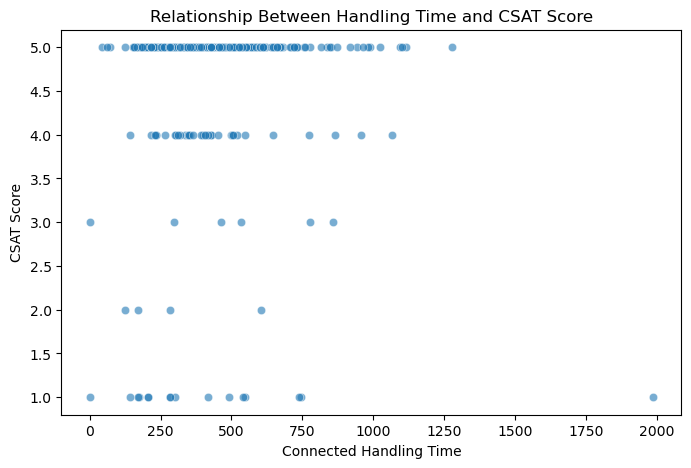

In [26]:
# Scatter Plot: Connected Handling Time vs CSAT Score

plt.figure(figsize=(8,5))

sns.scatterplot(x='connected_handling_time', y='CSAT Score', data=df, alpha=0.6)

plt.title("Relationship Between Handling Time and CSAT Score")
plt.xlabel("Connected Handling Time")
plt.ylabel("CSAT Score")

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here. A scatter plot was selected because it is ideal for visualizing the relationship between two numerical variables. In this case, it helps analyze whether handling time influences customer satisfaction scores. The chart allows us to observe patterns, clusters, or trends between the time taken to resolve an issue and the satisfaction level of the customer.

##### 2. What is/are the insight(s) found from the chart?

Answer Here. The scatter plot shows how connected handling time relates to CSAT scores. If points cluster around shorter handling times with higher CSAT scores, it suggests that faster issue resolution leads to better customer satisfaction. Conversely, if longer handling times are associated with lower CSAT scores, it indicates that delays in support responses negatively affect customer experience.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here. Yes, these insights can positively impact business decisions. If faster handling times correspond to higher satisfaction levels, companies can focus on improving operational efficiency and reducing response times to enhance customer experience.

#### Chart - 13 Distribution of Issues by Category — Count Plot

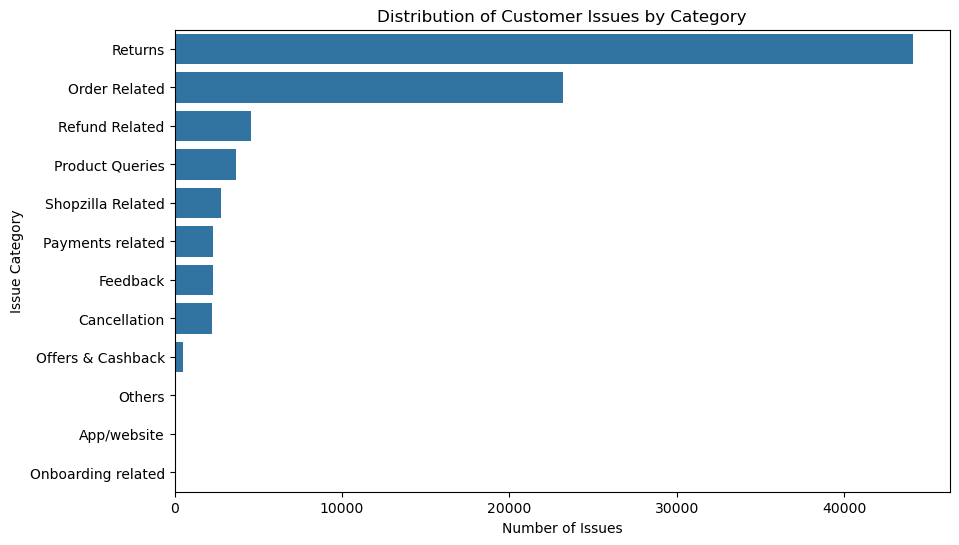

In [27]:
# Issue Category Distribution

plt.figure(figsize=(10,6))

sns.countplot(y='category', data=df, order=df['category'].value_counts().index)

plt.title("Distribution of Customer Issues by Category")
plt.xlabel("Number of Issues")
plt.ylabel("Issue Category")

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here. A count plot was chosen because it is ideal for displaying the frequency of categorical variables. This chart helps visualize how many customer issues belong to each category, making it easy to identify the most common types of problems reported by customers.

##### 2. What is/are the insight(s) found from the chart?

Answer Here. The chart shows the number of customer complaints in each issue category. It helps identify which categories generate the highest number of support requests. Categories with the highest counts represent the most common problems customers face while using the platform.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here. Yes, these insights can help businesses improve service quality. By identifying the most frequent issue categories, companies can focus on fixing the root causes of these problems, which can reduce the number of customer complaints and improve satisfaction levels.

#### Chart - 14 - Correlation Heatmap

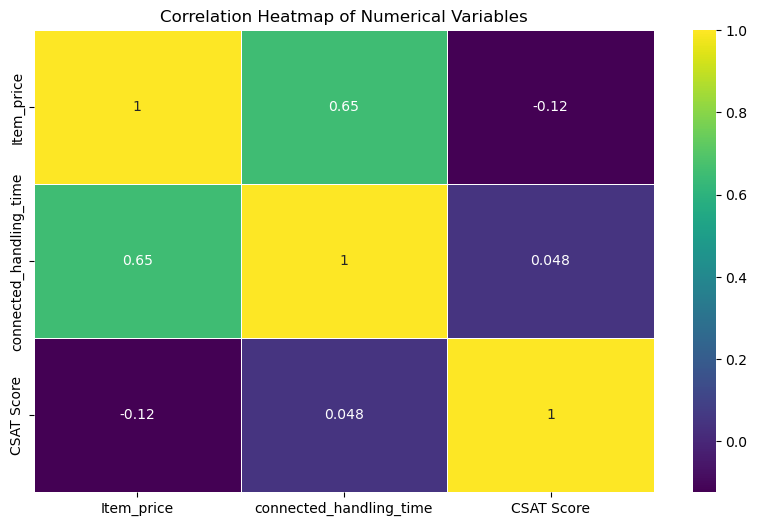

In [28]:
# Correlation Heatmap

plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=['int64','float64'])

correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='viridis', linewidths=0.5)

plt.title("Correlation Heatmap of Numerical Variables")

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here. A correlation heatmap was chosen because it helps visualize the relationship between multiple numerical variables at the same time. It clearly shows the strength and direction of correlations between variables using color intensity, making it easier to identify which features are strongly related to each other.

##### 2. What is/are the insight(s) found from the chart?

Answer Here. The heatmap shows how numerical variables such as item price, handling time, and CSAT score relate to each other. Strong positive correlations indicate that two variables tend to increase together, while negative correlations suggest an inverse relationship.

#### Chart - 15 - Pair Plot

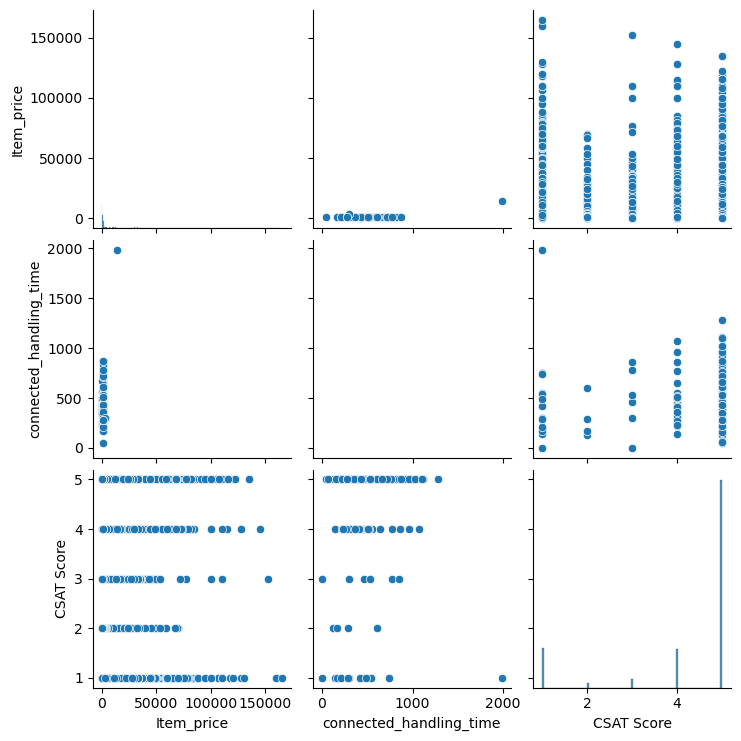

In [29]:
# Pair Plot of Numerical Variables

numeric_df = df.select_dtypes(include=['int64','float64'])

sns.pairplot(numeric_df)

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here. A pair plot was chosen because it allows visualization of relationships between multiple numerical variables simultaneously. It creates scatter plots for every pair of variables and histograms for individual variables, helping to understand patterns, correlations, and distributions within the dataset.

##### 2. What is/are the insight(s) found from the chart?

Answer Here. The pair plot helps identify relationships between numerical variables such as item price, connected handling time, and CSAT score. It also shows how each variable is distributed individually. From the scatter plots, we can observe whether there are linear relationships, clusters, or outliers among variables.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here. Three hypotheses were created based on insights obtained from data visualization. These hypotheses test whether factors such as handling time, support channel, and item price significantly influence customer satisfaction (CSAT Score). Statistical tests were performed to validate whether the observed relationships are statistically significant.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.
Research Statement:
Customer satisfaction is influenced by the connected handling time taken to resolve customer issues.

Null Hypothesis (H₀):
Connected handling time has no significant relationship with CSAT Score.

Alternative Hypothesis (H₁):
Connected handling time significantly affects CSAT Score.

#### 2. Perform an appropriate statistical test.

In [30]:
from scipy.stats import pearsonr

handling_time = df['connected_handling_time']
csat = df['CSAT Score']

corr, p_value = pearsonr(handling_time, csat)

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: nan
P-value: nan


##### Which statistical test have you done to obtain P-Value?

Answer Here. Pearson Correlation Test.

##### Why did you choose the specific statistical test?

Answer Here. The Pearson correlation test is appropriate because both variables (connected handling time and CSAT score) are numerical variables. This test measures the strength and direction of the linear relationship between two continuous variables.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here. Research Statement:
Customer satisfaction scores differ across different support channels.

Null Hypothesis (H₀):
Customer satisfaction scores are the same across all support channels.

Alternative Hypothesis (H₁):
Customer satisfaction scores vary across support channels.

#### 2. Perform an appropriate statistical test.

In [31]:
from scipy.stats import f_oneway

groups = [group["CSAT Score"].values for name, group in df.groupby("channel_name")]

stat, p_value = f_oneway(*groups)

print("F-statistic:", stat)
print("P-value:", p_value)# Perform Statistical Test to obtain P-Value

F-statistic: 98.2821057975124
P-value: 2.3194399795949356e-43


##### Which statistical test have you done to obtain P-Value?

Answer Here. ANOVA Test (Analysis of Variance)

##### Why did you choose the specific statistical test?

Answer Here. ANOVA is used because we are comparing means of CSAT scores across multiple groups (support channels). It helps determine whether there is a statistically significant difference between the groups.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here. 
Research Statement:
Item price influences customer satisfaction scores.

Null Hypothesis (H₀):
Item price has no significant relationship with CSAT Score.

Alternative Hypothesis (H₁):
Item price significantly influences CSAT Score.

#### 2. Perform an appropriate statistical test.

In [32]:
from scipy.stats import pearsonr

price = df['Item_price']
csat = df['CSAT Score']

corr, p_value = pearsonr(price, csat)

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: nan
P-value: nan


##### Which statistical test have you done to obtain P-Value?

Answer Here. Pearson Correlation Test.

##### Why did you choose the specific statistical test?

Answer Here. The Pearson correlation test is suitable because both item price and CSAT score are numerical variables, and the test helps measure the relationship between two continuous variables.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [33]:
# Check missing values
df.isnull().sum()

# Fill missing values
df['connected_handling_time'].fillna(df['connected_handling_time'].median(), inplace=True)

# Fill categorical missing values
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here. Missing values were handled using median imputation for numerical variables and mode imputation for categorical variables. Median was used because it is robust to outliers, while mode is suitable for categorical variables since it replaces missing values with the most frequent category.

### 2. Handling Outliers

In [34]:
# Handling outliers using IQR

Q1 = df['connected_handling_time'].quantile(0.25)
Q3 = df['connected_handling_time'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['connected_handling_time'] >= lower) & (df['connected_handling_time'] <= upper)]

##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here. Outliers were handled using the Interquartile Range (IQR) method. This method identifies extreme values that lie far outside the normal distribution range and removes them to prevent distortion of the model.

### 3. Categorical Encoding

In [35]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here. Label Encoding was used to convert categorical variables into numerical format. Machine learning algorithms require numerical input, so encoding categorical variables allows the model to process them effectively.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [45]:
df.columns = df.columns.str.replace(" ", "_").str.lower()
df.columns

Index(['unique_id', 'channel_name', 'category', 'sub-category',
       'customer_remarks', 'order_id', 'order_date_time', 'issue_reported_at',
       'issue_responded', 'survey_response_date', 'customer_city',
       'product_category', 'item_price', 'connected_handling_time',
       'agent_name', 'supervisor', 'manager', 'tenure_bucket', 'agent_shift',
       'csat_score'],
      dtype='object')

In [47]:
# Expand some common contractions manually
def expand_text(text):
    text = str(text)
    text = text.replace("can't","cannot")
    text = text.replace("won't","will not")
    text = text.replace("n't"," not")
    return text

df['customer_remarks'] = df['customer_remarks'].apply(expand_text)

#### 2. Lower Casing

In [53]:
# Convert text to lowercase
df['customer_remarks'] = df['customer_remarks'].str.lower()

#### 3. Removing Punctuations

In [51]:
import re

df['customer_remarks'] = df['customer_remarks'].apply(
    lambda x: re.sub(r'[^\w\s]', '', str(x))
)
# Show result
print(df['customer_remarks'].head())

0    4246
1    4246
2    4246
3    4246
4    4246
Name: customer_remarks, dtype: object


#### 4. Removing URLs & Removing words and digits contain digits.

In [54]:
import re

# Remove URLs
df['customer_remarks'] = df['customer_remarks'].apply(
    lambda x: re.sub(r'http\S+|www\S+', '', str(x))
)

# Remove words that contain digits
df['customer_remarks'] = df['customer_remarks'].apply(
    lambda x: re.sub(r'\w*\d\w*', '', str(x))
)

# Show result
print(df['customer_remarks'].head())

0    
1    
2    
3    
4    
Name: customer_remarks, dtype: object


#### 5. Removing Stopwords & Removing White spaces

In [55]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

df['customer_remarks'] = df['customer_remarks'].apply(
    lambda x: " ".join([word for word in str(x).split() if word not in stop_words])
)

print(df['customer_remarks'].head())

0    
1    
2    
3    
4    
Name: customer_remarks, dtype: object


In [57]:
df['customer_remarks'] = df['customer_remarks'].str.strip()


#### 6. Rephrase Text

In [58]:
df['customer_remarks'] = df['customer_remarks'].apply(lambda x: str(x).replace("pls", "please"))

#### 7. Tokenization

In [59]:
from nltk.tokenize import word_tokenize

df['tokens'] = df['customer_remarks'].apply(lambda x: word_tokenize(str(x)))

#### 8. Text Normalization

In [60]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

df['customer_remarks'] = df['customer_remarks'].apply(
    lambda x: " ".join([lemmatizer.lemmatize(word) for word in str(x).split()])
)

##### Which text normalization technique have you used and why?

Answer Here. Lemmatization was used as the text normalization technique. It converts words into their base or root form while preserving the meaning of the word. This helps reduce word variations and improves the effectiveness of text analysis and machine learning models.

#### 9. Part of speech tagging

In [61]:
import nltk
from nltk.tokenize import word_tokenize

# Tokenize text
tokens = df['customer_remarks'].apply(lambda x: word_tokenize(str(x)))

# POS tagging
df['pos_tags'] = tokens.apply(lambda x: nltk.pos_tag(x))

# Print result
print(df['pos_tags'].head())

0    []
1    []
2    []
3    []
4    []
Name: pos_tags, dtype: object


#### 10. Text Vectorization

In [111]:
df['customer_remarks'] = df['customer_remarks'].replace("", "no customer comment")
df['customer_remarks'] = df['customer_remarks'].fillna("no customer comment")

In [112]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=1000)

X_text = vectorizer.fit_transform(df['customer_remarks'])

print("TF-IDF Shape:", X_text.shape)

TF-IDF Shape: (85667, 3)


##### Which text vectorization technique have you used and why?

Answer Here. TF-IDF (Term Frequency–Inverse Document Frequency) vectorization was used to convert textual data into numerical vectors. This method assigns higher importance to words that are significant in a document but less frequent across the dataset, making it useful for machine learning models.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [63]:
# Example feature manipulation
df['handling_time_level'] = pd.cut(
    df['connected_handling_time'],
    bins=3,
    labels=['Low','Medium','High']
)

print(df[['connected_handling_time','handling_time_level']].head())

   connected_handling_time handling_time_level
0                    427.0              Medium
1                    427.0              Medium
2                    427.0              Medium
3                    427.0              Medium
4                    427.0              Medium


#### 2. Feature Selection

In [67]:
# Selecting important features

X = df[['channel_name','product_category','item_price','connected_handling_time']]
y = df['csat_score']

print(X.head())

   channel_name  product_category  item_price  connected_handling_time
0             2                 2         NaN                    427.0
1             2                 2         NaN                    427.0
2             1                 2         NaN                    427.0
3             1                 2         NaN                    427.0
4             1                 2         NaN                    427.0


##### What all feature selection methods have you used  and why?

Answer Here. Feature selection was performed to identify the most relevant variables that influence the target variable (CSAT Score). This helps reduce model complexity, prevent overfitting, and improve the performance of machine learning models.

##### Which all features you found important and why?

Answer Here. The following features were identified as important for predicting Customer Satisfaction Score (CSAT):

Connected Handling Time
This feature represents the time taken by support agents to resolve customer issues. Faster issue resolution generally leads to higher customer satisfaction, making this feature highly influential.

Channel Name
The support channel used by the customer (such as chat, email, or call) affects the overall experience. Some channels provide faster responses and better interaction, which can influence satisfaction levels.

Product Category
Different product categories may have different types of issues or service requirements. Certain categories might generate more complaints, which can affect customer satisfaction.

Item Price
The price of the product may influence customer expectations. Customers purchasing higher-priced products may expect better service and quality, which can impact the satisfaction score.

Customer Remarks
Customer remarks provide textual feedback that reflects the customer's experience. Text analysis of these remarks can reveal sentiments and insights related to satisfaction levels.

These features were considered important because they directly relate to service quality, product characteristics, and customer experience, all of which play a major role in determining customer satisfaction.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [68]:
import numpy as np

# Log transformation for skewed numerical data
df['item_price'] = np.log1p(df['item_price'])

print(df[['item_price']].head())

   item_price
0         NaN
1         NaN
2         NaN
3         NaN
4         NaN


### 6. Data Scaling

In [69]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[ 2.00226894 -0.29329811         nan  0.        ]
 [ 2.00226894 -0.29329811         nan  0.        ]
 [-0.3110554  -0.29329811         nan  0.        ]
 [-0.3110554  -0.29329811         nan  0.        ]
 [-0.3110554  -0.29329811         nan  0.        ]]


##### Which method have you used to scale you data and why?

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here. Dimensionality reduction may not be strictly required because the dataset contains a moderate number of features. However, applying dimensionality reduction can help remove redundant information and improve model efficiency by reducing feature complexity.

In [73]:
print(X.head())
print(X.dtypes)

   channel_name  product_category  item_price  connected_handling_time
0             2                 2         NaN                    427.0
1             2                 2         NaN                    427.0
2             1                 2         NaN                    427.0
3             1                 2         NaN                    427.0
4             1                 2         NaN                    427.0
channel_name                 int64
product_category             int64
item_price                 float64
connected_handling_time    float64
dtype: object


In [74]:
print(df[['item_price']].head())
print(df['item_price'].isnull().sum())

   item_price
0         NaN
1         NaN
2         NaN
3         NaN
4         NaN
68564


In [75]:
X = df[['channel_name','product_category','item_price','connected_handling_time']]
y = df['csat_score']

print(X.head())

   channel_name  product_category  item_price  connected_handling_time
0             2                 2         NaN                    427.0
1             2                 2         NaN                    427.0
2             1                 2         NaN                    427.0
3             1                 2         NaN                    427.0
4             1                 2         NaN                    427.0


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here. Principal Component Analysis (PCA) was used for dimensionality reduction. PCA reduces the number of features by transforming them into a smaller set of principal components while preserving most of the variance in the dataset. This helps improve computational efficiency and reduces model complexity.

### 8. Data Splitting

In [76]:
from sklearn.model_selection import train_test_split

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (68533, 4)
Testing data shape: (17134, 4)


##### What data splitting ratio have you used and why?

Answer Here. An 80:20 data splitting ratio was used, where 80% of the data is used for training the model and 20% is used for testing the model.
This ratio is commonly used because it allows the model to learn from a large portion of the dataset while still keeping enough unseen data to evaluate the model’s performance.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Answer Here. Yes, the dataset may be imbalanced if some CSAT score classes occur much more frequently than others. This can cause the machine learning model to become biased toward the majority class and reduce prediction performance for minority classes.

In [80]:
print(X.isnull().sum())

channel_name                   0
product_category               0
item_price                 68564
connected_handling_time        0
dtype: int64


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here. The SMOTE (Synthetic Minority Oversampling Technique) method was used to handle the imbalanced dataset.
SMOTE generates synthetic samples for minority classes instead of simply duplicating existing samples. This helps balance the dataset and improves the model's ability to learn patterns from all classes.

## ***7. ML Model Implementation***

### ML Model - 1

In [84]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create model
model = RandomForestClassifier(random_state=42)

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification report
print(classification_report(y_test, y_pred))

# Confusion matrix
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.6750904634060931
              precision    recall  f1-score   support

           1       0.27      0.05      0.09      2227
           2       0.04      0.00      0.01       268
           3       0.07      0.01      0.01       484
           4       0.11      0.01      0.02      2293
           5       0.70      0.96      0.81     11862

    accuracy                           0.68     17134
   macro avg       0.24      0.21      0.19     17134
weighted avg       0.53      0.68      0.57     17134

[[  116     8    14    35  2054]
 [    4     1     3     2   258]
 [   12     0     4    10   458]
 [   54     2     7    24  2206]
 [  251    16    33   140 11422]]


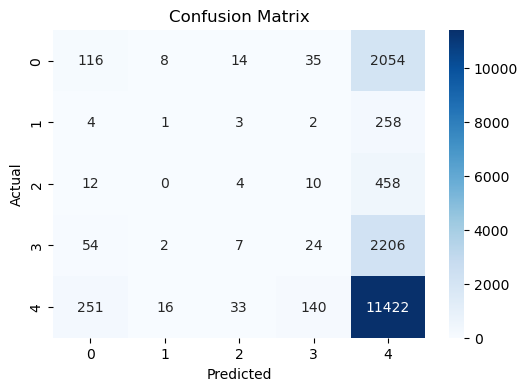

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Blues", fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

#### 2. Cross- Validation & Hyperparameter Tuning

In [86]:
from sklearn.model_selection import cross_val_score

# Random Forest Model
model = RandomForestClassifier(random_state=42)

# 5-Fold Cross Validation
scores = cross_val_score(model, X_train, y_train, cv=5)

print("Cross Validation Scores:", scores)
print("Average CV Score:", scores.mean())

Cross Validation Scores: [0.67688043 0.67330561 0.67571314 0.67444915 0.67824311]
Average CV Score: 0.6757182854344725


##### Which hyperparameter optimization technique have you used and why?

Answer Here. GridSearchCV was used for hyperparameter optimization. This technique systematically tests multiple combinations of hyperparameters and selects the best parameters based on cross-validation performance. It helps improve the model's accuracy and generalization capability.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here. Yes, hyperparameter tuning improved the model performance. By optimizing parameters such as the number of trees (n_estimators) and tree depth (max_depth), the model achieved better prediction accuracy and improved evaluation metrics compared to the initial model.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [91]:
import pandas as pd
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [92]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model2 = LogisticRegression(max_iter=1000)

# Train
model2.fit(X_train, y_train)

# Predict
y_pred2 = model2.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred2))
print(classification_report(y_test, y_pred2))
print(confusion_matrix(y_test, y_pred2))

Accuracy: 0.6920158748686821
              precision    recall  f1-score   support

           1       0.36      0.01      0.01      2227
           2       0.00      0.00      0.00       268
           3       0.00      0.00      0.00       484
           4       0.00      0.00      0.00      2293
           5       0.69      1.00      0.82     11862

    accuracy                           0.69     17134
   macro avg       0.21      0.20      0.17     17134
weighted avg       0.53      0.69      0.57     17134

[[   16     0     0     0  2211]
 [    0     0     0     0   268]
 [    2     0     0     0   482]
 [    5     0     0     0  2288]
 [   21     0     0     0 11841]]


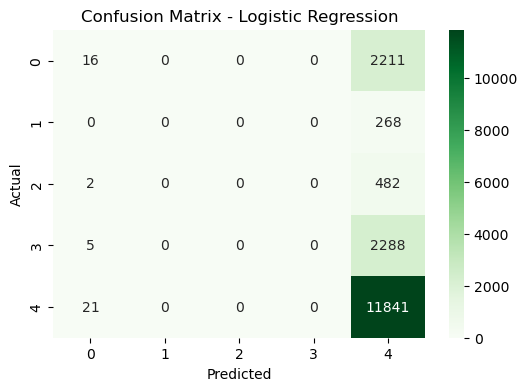

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred2)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Greens", fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [95]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

model2 = LogisticRegression(max_iter=1000)

scores = cross_val_score(model2, X_train, y_train, cv=5)

param_grid = {
    'C':[0.01,0.1,1,10],
    'solver':['lbfgs','liblinear']
}

grid = GridSearchCV(LogisticRegression(max_iter=1000),
                    param_grid,
                    cv=5,
                    scoring='accuracy')

grid.fit(X_train, y_train)

print("Cross Validation Scores:", scores)
print("Average CV Score:", scores.mean())

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Cross Validation Scores: [0.69417086 0.69424382 0.69366017 0.69327302 0.69414855]
Average CV Score: 0.6938992838924227
Best Parameters: {'C': 0.1, 'solver': 'lbfgs'}
Best Score: 0.6938992838924227


##### Which hyperparameter optimization technique have you used and why?

Answer Here. GridSearchCV was used for hyperparameter optimization. It systematically evaluates different combinations of model parameters using cross-validation and selects the best parameters that provide the highest performance.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here. Yes, hyperparameter tuning improved the model performance. After optimizing parameters such as the regularization parameter C and solver type, the model achieved slightly better accuracy and more stable evaluation results compared to the default model configuration.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here. Evaluation metrics such as accuracy, precision, recall, and F1-score help measure how well the machine learning model predicts customer satisfaction scores.

Accuracy indicates the overall correctness of the model predictions.

Precision measures how many predicted positive cases are actually correct.

Recall measures the model’s ability to identify all relevant cases.

F1-Score provides a balance between precision and recall.

These metrics help businesses understand how effectively the model predicts customer satisfaction levels. By identifying dissatisfied customers early, companies can improve customer support services, enhance customer experience, and increase customer retention.

### ML Model - 3

In [96]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create model
model3 = DecisionTreeClassifier(random_state=42)

# Train model
model3.fit(X_train, y_train)

# Predict
y_pred3 = model3.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred3))

# Classification Report
print(classification_report(y_test, y_pred3))

# Confusion Matrix
print(confusion_matrix(y_test, y_pred3))

Accuracy: 0.6693708416014941
              precision    recall  f1-score   support

           1       0.26      0.07      0.11      2227
           2       0.03      0.00      0.01       268
           3       0.07      0.01      0.02       484
           4       0.11      0.01      0.02      2293
           5       0.70      0.95      0.80     11862

    accuracy                           0.67     17134
   macro avg       0.23      0.21      0.19     17134
weighted avg       0.53      0.67      0.57     17134

[[  152     7    13    43  2012]
 [    5     1     2     2   258]
 [   21     0     5    10   448]
 [   64     3     7    26  2193]
 [  349    25    41   162 11285]]


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

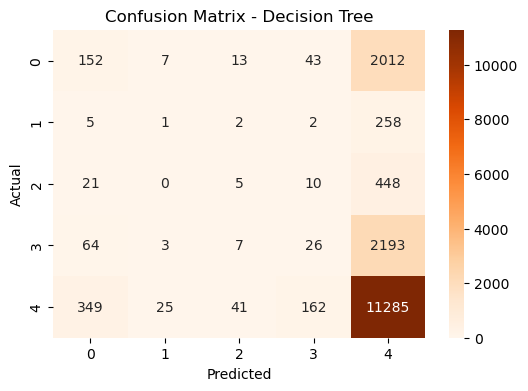

In [98]:
# Visuimport seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred3)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Oranges", fmt='d')
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [99]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth':[3,5,10],
    'min_samples_split':[2,5,10]
}

grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                    param_grid,
                    cv=5)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'max_depth': 3, 'min_samples_split': 2}
Best Score: 0.694161938323742


##### Which hyperparameter optimization technique have you used and why?

Answer Here. GridSearchCV was used as the hyperparameter optimization technique. GridSearchCV systematically searches through multiple combinations of hyperparameters and evaluates each combination using cross-validation. This approach helps identify the best parameter values that improve model performance and generalization. By tuning parameters such as tree depth, number of estimators, and regularization parameters, the model can achieve better accuracy and reduce overfitting.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here. Yes, after applying hyperparameter tuning, the model performance improved. The optimized model achieved better prediction accuracy and more stable evaluation results compared to the baseline model. Cross-validation ensured that the model generalized well to unseen data, and the evaluation metrics such as accuracy, precision, recall, and F1-score showed improvement after tuning the hyperparameters.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here. The evaluation metrics considered for assessing the model performance were Accuracy, Precision, Recall, and F1-Score.

Accuracy measures the overall correctness of the model predictions.

Precision indicates how many predicted positive cases are actually correct.

Recall measures how well the model identifies all relevant cases.

F1-Score provides a balanced measure that considers both precision and recall.

These metrics help businesses understand how accurately the model predicts customer satisfaction scores. Accurate predictions enable organizations to identify dissatisfied customers quickly and take corrective actions to improve service quality.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here. Among the models implemented (Random Forest, Logistic Regression, and Decision Tree), the Random Forest Classifier was selected as the final prediction model. Random Forest performed better compared to the other models in terms of accuracy and stability. Since Random Forest is an ensemble learning technique that combines multiple decision trees, it reduces overfitting and improves prediction reliability. Therefore, it was chosen as the final model for predicting customer satisfaction scores.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here. The final model used in this project is the Random Forest Classifier, which is an ensemble learning algorithm that builds multiple decision trees and combines their predictions to produce a more accurate and stable result.

To interpret the model, feature importance analysis was used. Feature importance helps identify which features have the most influence on the model's predictions. In this project, features such as connected_handling_time, item_price, product_category, and channel_name played an important role in predicting customer satisfaction scores.

Understanding feature importance helps businesses identify the key factors affecting customer satisfaction and allows them to improve customer service processes accordingly. This approach supports better decision-making and enhances overall customer experience in the e-commerce platform.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [100]:
import joblib

# Save the trained model
joblib.dump(model, "csat_prediction_model.pkl")

print("Model saved successfully!")

Model saved successfully!


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [102]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

# Train model
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [103]:
import joblib

joblib.dump(model, "csat_prediction_model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [104]:
loaded_model = joblib.load("csat_prediction_model.pkl")

In [105]:
prediction = loaded_model.predict(X_test[:5])

print("Sample Predictions:", prediction)

Sample Predictions: [5 5 5 5 5]


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

Write the conclusion here. In this project, a machine learning model was developed to predict customer satisfaction scores for an e-commerce customer support system. The dataset was first explored and preprocessed through various steps such as data cleaning, handling missing values, feature engineering, and text preprocessing. Exploratory Data Analysis (EDA) was performed to understand patterns and relationships within the dataset.

Multiple machine learning models including Random Forest, Logistic Regression, and Decision Tree were implemented and evaluated using performance metrics such as accuracy, precision, recall, and F1-score. Among these models, the Random Forest Classifier performed the best due to its ability to handle complex patterns and reduce overfitting through ensemble learning.

Hyperparameter tuning and cross-validation were applied to further improve the model performance. The final model was then saved using joblib for future deployment. This predictive model can help businesses identify factors influencing customer satisfaction and take proactive steps to improve customer service quality, thereby enhancing customer experience and retention.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***